In [2]:
import sys
print(sys.version)

3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]


In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import streamlit

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [5]:
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
sns.set(style="whitegrid")

In [6]:
import pandas as pd
df=pd.read_csv("C:/Users/anubh/OneDrive/Desktop/AIML Dataset.csv")

In [7]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [9]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [10]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.shape[0]

6362620

In [14]:
round((df["isFraud"].value_counts()[1]/df.shape[0])*100,2)

np.float64(0.13)

<function matplotlib.pyplot.show(close=None, block=None)>

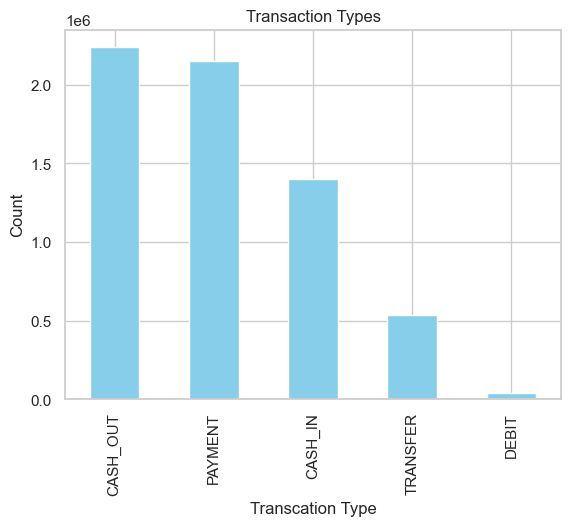

In [15]:
df['type'].value_counts().plot(kind="bar",title="Transaction Types", color="skyblue")
plt.xlabel("Transcation Type")
plt.ylabel("Count")
plt.show

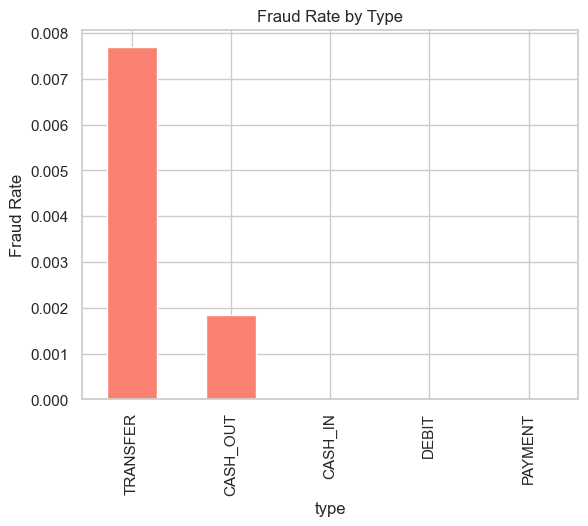

In [16]:
fraud_by_type=df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [17]:
# amount statistics 
df["amount"].describe().astype(int)


count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

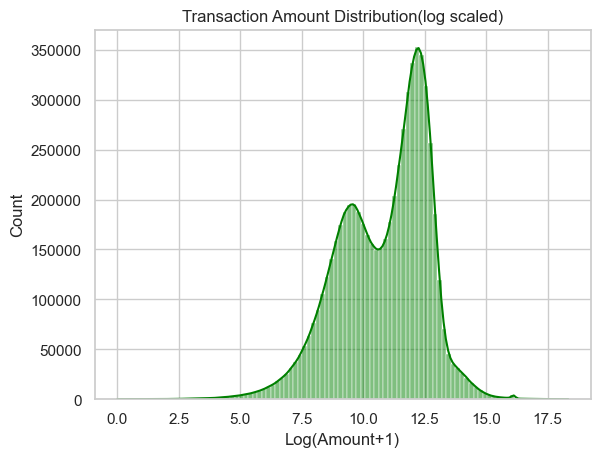

In [18]:
#getting histogram of this
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="green")
plt.title("Transaction Amount Distribution(log scaled)")
plt.xlabel("Log(Amount+1)")
plt.show()

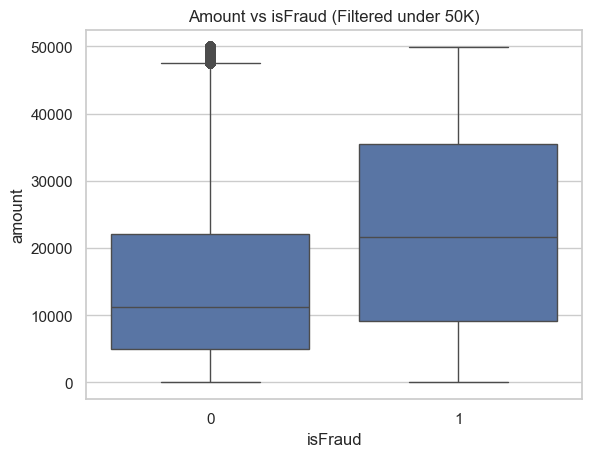

In [19]:
# relationship between fraud and amount
sns.boxplot(data=df[df["amount"]<50000], x= "isFraud", y="amount")
plt.title("Amount vs isFraud (Filtered under 50K)")
plt.show()

In [20]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [21]:
# checking balance difference and anomalies
df["balanceDiffOrig"]=df["oldbalanceOrg"]-df["newbalanceOrig"]
df["balanceDiffDest"]=df["newbalanceDest"]- df["oldbalanceDest"]


In [22]:
#to chcek if we have any negative value
# means negative is there on original side
(df["balanceDiffOrig"]< 0).sum()

np.int64(1399253)

In [23]:
# we have lower value than original but it is still a large value
(df["balanceDiffDest"]< 0).sum()

np.int64(1238864)

In [24]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='str')

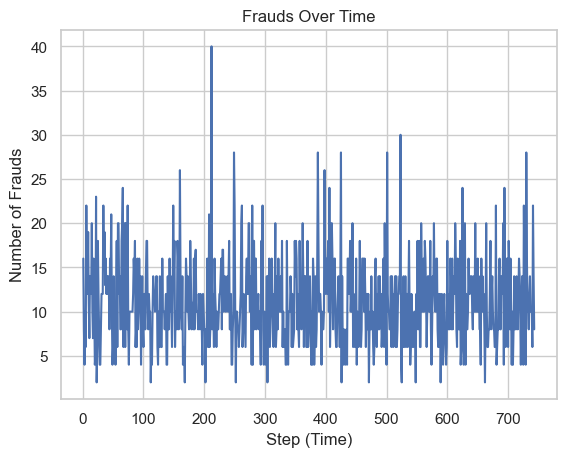

In [25]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()

plt.plot(
    frauds_per_step.index,
    frauds_per_step.values,
    label="Frauds per Step"
)

plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [26]:
# since it is not dependent on time hence we will not use step and we will drop it
df.drop(columns="step", inplace =True)

In [27]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [28]:
#to know about customers who had the highest transaction i.e. top sender and top receiver
top_sender=df["nameOrig"].value_counts().head(10)

In [29]:
top_sender

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [30]:
top_receivers= df["nameDest"].value_counts().head(10)

In [31]:
top_receivers # hence we can see we dont have any equality on both the sides

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [32]:
#we are analysing fraud making customers
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)

In [33]:
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [34]:
# we can see transfer and cash out are most common way of transaction for fraud which we saw from the plot
fraud_types=df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

In [35]:
fraud_types.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [36]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

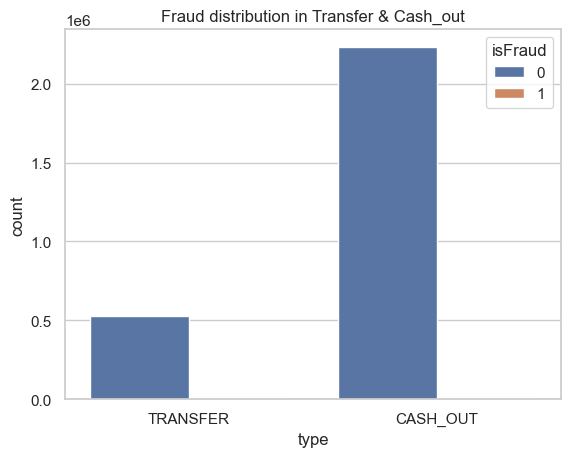

In [37]:
#using seaborn plotting a count plot on it
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud distribution in Transfer & Cash_out")
plt.show()

In [38]:
# now we are going to look for correlation matrix
corr= df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [39]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


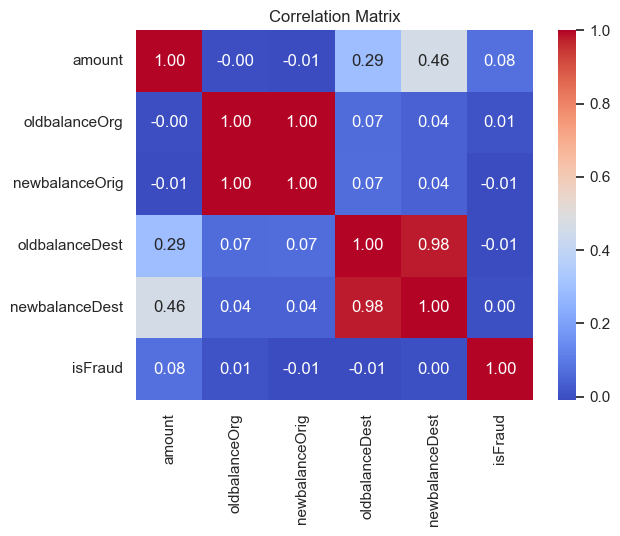

In [40]:
#we can  visualise this using seaborn heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()   
# there is high correlation between newbalance dest and high balance dest i.e.0.98 which is normal
# correlation matrix can  take -1 to +1 values. -1 value means strong negative relationship and +1 means strong positive relationship
#0 means they do not have any relationship

In [41]:
# now need to filter customers who has balance and after transfer they go to zero
zero_after_transfer= df[
       (df["oldbalanceOrg"]>0) &
       (df["newbalanceOrig"]==0) &
       (df["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [42]:
len(zero_after_transfer)

1188074

In [43]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [44]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [45]:
#feature engineering and training various models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [46]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [47]:
df_model=df.drop(["nameOrig","nameDest","isFlaggedFraud"], axis=1)

In [48]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [49]:
categorical=["type"]
numeric=["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [50]:
y= df_model["isFraud"]
X = df_model.drop("isFraud", axis=1)

In [51]:
#train-test split (30 percent data into testing and 70 percent into training the model)
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.3, stratify=y)

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder="drop"
)

In [53]:
# now creating model pipeline
# this step is important and 99% of our data is not fraud and so it will always predict not fraud if we dont set class weight to balanced

pipeline= Pipeline([
    ("prep",preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000) )
])

In [54]:
#training the model
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [55]:
y_pred = pipeline.predict(X_test)

In [56]:
print(classification_report(y_test,y_pred)) #precision is not that good

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.95      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.95      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [57]:
confusion_matrix(y_test, y_pred)

array([[1802529,  103793],
       [    132,    2332]])

In [58]:
pipeline.score(X_test, y_test)*100

94.55543994979007

In [ ]:
#evaluating different threshold values
"""from sklearn.metrics import precision_score, recall_score

y_prob = pipeline.predict_proba(X_test)[:,1]

for threshold in [0.5,0.6,0.7,0.8,0.9,0.95]:
    
    y_pred_new = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_new)
    recall = recall_score(y_test, y_pred_new)

    print(
        f"Threshold={threshold:.2f} "
        f"Precision={precision:.4f} "
        f"Recall={recall:.4f}"
    )"""

Threshold=0.50 Precision=0.0220 Recall=0.9464
Threshold=0.60 Precision=0.0292 Recall=0.9176
Threshold=0.70 Precision=0.0402 Recall=0.8892
Threshold=0.80 Precision=0.0588 Recall=0.8462
Threshold=0.90 Precision=0.0972 Recall=0.7744
Threshold=0.95 Precision=0.1472 Recall=0.7171


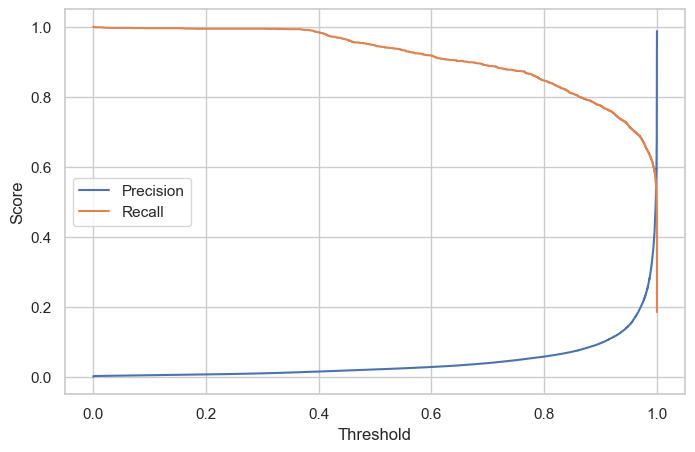

In [ ]:
#plotting precision vs threshold
"""from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1],
         label="Precision")

plt.plot(thresholds, recall[:-1],
         label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()"""

In [ ]:
#Due to the large size of the dataset, 
# model comparison was performed on a stratified sample of 200,000 records, 
# while Logistic Regression was selected for deployment due to faster training and lower computational cost
# imports
"""import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


from xgboost import XGBClassifier"""

In [ ]:
# features
"""categorical = ["type"]

numeric = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

# target
y = df_model["isFraud"]
X = df_model[categorical + numeric]"""

In [ ]:
# stratified sample to make training faster
"""df_sample, _ = train_test_split(
    df_model,
    train_size=200000,
    stratify=df_model["isFraud"],
    random_state=42
)

X_sample = df_sample[categorical + numeric]
y_sample = df_sample["isFraud"]"""

In [ ]:
# stratified train-test split
"""X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sample,
    y_sample,
    test_size=0.3,
    stratify=y_sample,
    random_state=42
)"""

In [ ]:
# preprocessing
"""preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical)
    ],
    remainder="drop"
)"""

In [ ]:
# models
"""models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=30,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=50,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=50,
        max_depth=4,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}"""

In [ ]:
# comparison
"""results = []

for name, model in models.items():

    model_pipeline = Pipeline([
        ("prep", preprocessor),
        ("clf", model)
    ])

    model_pipeline.fit(X_train_s, y_train_s)

    y_pred = model_pipeline.predict(X_test_s)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_s, y_pred),
        "Precision": precision_score(y_test_s, y_pred, zero_division=0),
        "Recall": recall_score(y_test_s, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test_s, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print(results_df)"""

                 Model  Accuracy  Precision    Recall  F1 Score
4              XGBoost  0.999550   1.000000  0.649351  0.787402
2        Random Forest  0.995633   0.204473  0.831169  0.328205
3    Gradient Boosting  0.998867   0.714286  0.194805  0.306122
1        Decision Tree  0.992033   0.115163  0.779221  0.200669
0  Logistic Regression  0.946550   0.022283  0.948052  0.043543


In [ ]:
"""for name, model in models.items():

    model_pipeline = Pipeline([
        ("prep", preprocessor),
        ("clf", model)
    ])

    model_pipeline.fit(X_train_s, y_train_s)
    y_pred = model_pipeline.predict(X_test_s)

    print("\n==============================")
    print(name)
    print("==============================")
    print(classification_report(y_test_s, y_pred, zero_division=0))"""


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     59923
           1       0.02      0.95      0.04        77

    accuracy                           0.95     60000
   macro avg       0.51      0.95      0.51     60000
weighted avg       1.00      0.95      0.97     60000


Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     59923
           1       0.12      0.78      0.20        77

    accuracy                           0.99     60000
   macro avg       0.56      0.89      0.60     60000
weighted avg       1.00      0.99      0.99     60000


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59923
           1       0.20      0.83      0.33        77

    accuracy                           1.00     60000
   macro avg       0.60      0.91      0.66     60000
weighted avg       1.00

In [ ]:
#Although XGBoost achieved the best precision and F1-score, Logistic Regression was selected for deployment because it is lightweight, interpretable, faster to train, easier to deploy, and suitable for real-time fraud screening. 
# It also achieved high fraud recall, meaning it can identify most fraudulent transactions. 
# Since fraud detection prioritizes minimizing missed fraud cases, Logistic Regression is acceptable as a baseline deployment model.
#The low precision of Logistic Regression indicates a high false-positive rate. Future improvement can be 
# done using threshold tuning, feature engineering, and ensemble models like XGBoost.
# Logistic Regression was deployed as a baseline real-time fraud detection model due to its simplicity, 
# speed, and interpretability, while XGBoost was retained as the best-performing benchmark model for future enhancement.

In [76]:
import joblib

joblib.dump(pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']